Total number of cells: 1576411


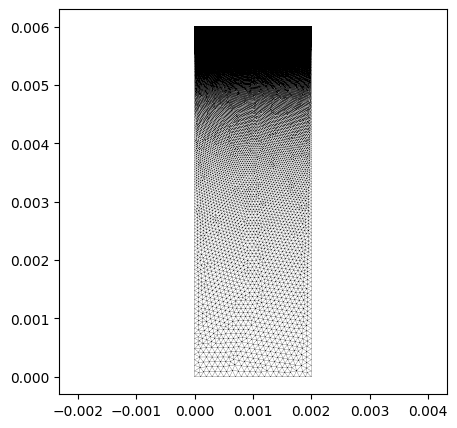

In [33]:
from dolfin import *
from mshr import *
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

mesh = Mesh()
filename = "./mesh_v5/mesh.xdmf"
with XDMFFile(MPI.comm_world, filename) as infile:
    infile.read(mesh)

n = mesh.num_vertices()
d = mesh.geometry().dim()

# Create the triangulation
mesh_coordinates = mesh.coordinates().reshape((n, d))
triangles = np.asarray([cell.entities(0) for cell in cells(mesh)])
print(f"Total number of cells: {len(triangles)}")

triangulation = tri.Triangulation(
    mesh_coordinates[:, 0], mesh_coordinates[:, 1], triangles
)

plt.figure(figsize=(5, 5))
plt.triplot(triangulation, color="black", lw=0.15)
plt.axis("equal")
plt.show()

In [35]:
from dolfin import *
import fenics as f
import matplotlib.pyplot as plt
from dolfin_pyvista_adapter import plot

mesh = Mesh()
filename = "./flux_1ms_E1.003_1225139/mesh/mesh.xdmf"
with XDMFFile(MPI.comm_world, filename) as infile:
    infile.read(mesh)


V = FunctionSpace(mesh,'DG',1)
retention = f.Function(V, name="retention")
filename = "./flux_1ms_E1.003_1225139/res/ret.xdmf"
f.XDMFFile(filename).read_checkpoint(retention, "retention", -1)

plot(retention)

RuntimeError: Unsupported d_cell=Cell('triangle', 3)